Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 26,742,673 (102.02 MB)

 Trainable params: 1,051,653 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 2,103,308 (8.02 MB)

                precision    recall  f1-score   support

         No_DR       0.90      0.93      0.92       351
          Mild       0.26      0.21      0.23        68
      Moderate       0.61      0.74      0.67       213
        Severe       0.33      0.17      0.22        36
Proliferate_DR       0.30      0.18      0.23        65

      accuracy                           0.70       733
     macro avg       0.48      0.45      0.45       733
  weighted avg       0.68      0.70      0.69       733



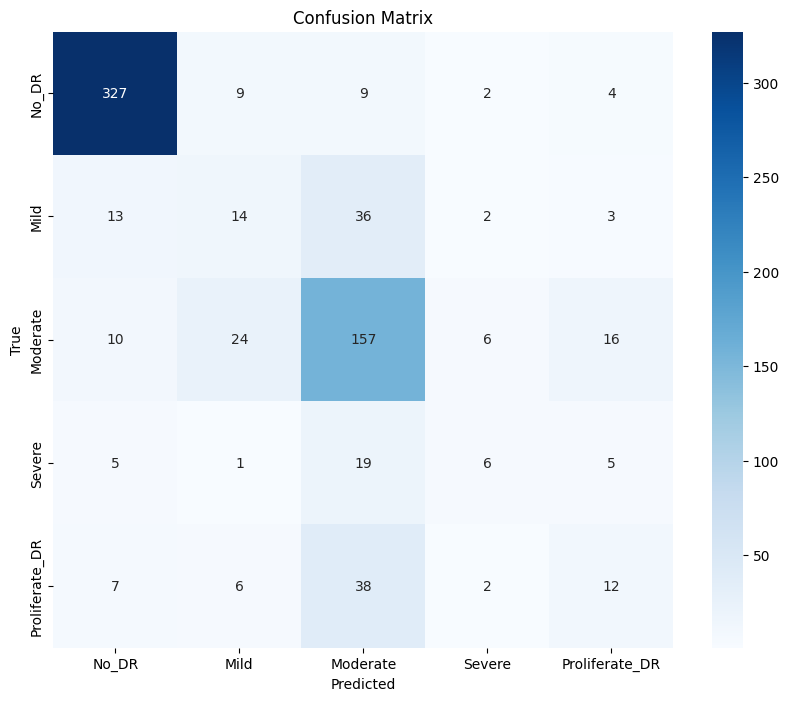

In [1]:
import numpy as np
import os
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_data, preprocess_image

# Load the pre-trained ResNet model
def load_ResNet_model(model_path):
    model = tf.keras.models.load_model(model_path)
    model.summary()
    return model

# Extract features from a chosen convolutional layer
def extract_features(model, img_array, layer_name='conv5_block3_out'):
    feature_extractor = tf.keras.Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
    features = feature_extractor(img_array)
    return features.numpy().flatten()

# Train a Decision Tree classifier as a surrogate
def train_decision_tree(features, original_predictions, decision_tree):
    decision_tree.fit(features, original_predictions)
    return decision_tree

# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Main workflow to train Decision Tree and explain ResNet
def explain_ResNet_with_decision_tree(X_train, X_test, y_train, y_test, model_path, csv_file, base_image_dir, decision_tree):
    model = load_ResNet_model(model_path)
    
    # Prepare data
    # X_train, X_test, y_train, y_test = load_data(csv_file, base_image_dir)
    feature_list_train = []
    feature_list_test = []
    
    # Extract features for training data
    for img_path in X_train:
        img_array = preprocess_image(img_path)
        features = extract_features(model, img_array)
        feature_list_train.append(features)
    
    # Extract features for testing data
    for img_path in X_test:
        img_array = preprocess_image(img_path)
        features = extract_features(model, img_array)
        feature_list_test.append(features)
    
    # Train a Decision Tree using extracted features
    decision_tree = train_decision_tree(feature_list_train, y_train, decision_tree)
    
    # Make predictions on the test set
    y_pred = decision_tree.predict(feature_list_test)
    
    # Evaluate the model
    class_names = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    # Plot confusion matrix
    plot_confusion_matrix(y_test, y_pred, class_names)

# Usage
model_path = '../models/resnet50_model.keras'  # Path to your trained ResNet model
csv_file = '../archive/train.csv'  # Path to your dataset CSV
base_image_dir = '../archive/gaussian_filtered_images'  # Path to your image directory
decision_tree = DecisionTreeClassifier(max_depth=10, random_state=42)
X_train, X_test, y_train, y_test = load_data(csv_file, base_image_dir)

explain_ResNet_with_decision_tree(X_train, X_test, y_train, y_test, model_path, csv_file, base_image_dir, decision_tree)


In [2]:
import joblib

# Save the trained Decision Tree model
model_save_path = '../models/resnet50_beta.pkl'
joblib.dump(decision_tree, model_save_path)

print(f"Decision Tree model saved at {model_save_path}")

Decision Tree model saved at ../models/resnet50_beta.pkl


In [3]:
import joblib
import numpy as np
from sklearn.metrics import accuracy_score

# Load the Decision Tree model
decision_tree_path = '../models/resnet50_beta.pkl'
decision_tree = joblib.load(decision_tree_path)

# Load the ResNet model
ResNet_model_path = '../models/resnet50_model.keras'
ResNet_model = tf.keras.models.load_model(ResNet_model_path)

# Function to calculate fidelity
def calculate_fidelity(ResNet_model, decision_tree, X_test):
    ResNet_predictions = []
    decision_tree_predictions = []
    
    # Get predictions from both models
    for img_path in X_test:
        img_array = preprocess_image(img_path)
        
        # ResNet predictions
        ResNet_pred = ResNet_model.predict(img_array)
        ResNet_predictions.append(np.argmax(ResNet_pred))
        
        # Decision Tree predictions
        features = extract_features(ResNet_model, img_array)
        decision_tree_pred = decision_tree.predict([features])[0]
        decision_tree_predictions.append(decision_tree_pred)
    
    # Calculate fidelity as accuracy of decision tree mimicking ResNet
    fidelity = accuracy_score(ResNet_predictions, decision_tree_predictions)
    return fidelity

# Function to calculate unambiguity (using depth of the tree)
def calculate_unambiguity(decision_tree):
    tree_depth = decision_tree.get_depth()
    return 1 / (tree_depth + 1)  # Higher depth = lower unambiguity

# Function to calculate interpretability (using number of nodes)
def calculate_interpretability(decision_tree):
    num_nodes = decision_tree.tree_.node_count
    return 1 / (num_nodes + 1)  # Fewer nodes = higher interpretability

# Example of calculating metrics
fidelity = calculate_fidelity(ResNet_model, decision_tree, X_test)  # X_test should be the test dataset paths
unambiguity = calculate_unambiguity(decision_tree)
interpretability = calculate_interpretability(decision_tree)

print(f"Fidelity: {fidelity}")
print(f"Unambiguity: {unambiguity}")
print(f"Interpretability: {interpretability}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━